 # Credit Card Fraud Detection / Almog Miron

The goal of this project is to build a binary classification model that identifies fraudulent credit-card transactions.

The dataset contains 284,807 transactions, including PCA-transformed features V1–V28, transaction Time, transaction Amount, and the binary target Class, where 1 represents fraud.

A major challenge is the severe class imbalance: only about 0.17% of transactions are fraudulent.

Because of this imbalance, accuracy is not an appropriate primary metric. Model performance will mainly be evaluated using precision, recall, F1-score, and especially PR-AUC.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import randint, uniform, loguniform

from sklearn.base import clone
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

from sklearn.model_selection import (
    train_test_split,
    RandomizedSearchCV,
    StratifiedKFold,
    cross_val_score
)

from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    precision_score,
    recall_score,
    f1_score,
    average_precision_score,
    precision_recall_curve,
    roc_auc_score
)

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

file = "creditcardData.csv"
df0 = pd.read_csv(file)

print(df0.columns)

Index(['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
       'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
       'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount',
       'Class'],
      dtype='str')


In [2]:
# Observe the data structure
print(df0.head())

   Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024  ... -0.108300  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.817739  ... -0.009431  0.798278 -0.137458  0.141267 -0.206010   

        V26       V27       V28 

In [3]:
# Observe basic info about the df
print(df0.describe())

                Time            V1            V2            V3            V4  \
count  284807.000000  2.848070e+05  2.848070e+05  2.848070e+05  2.848070e+05   
mean    94813.859575  1.175161e-15  3.384974e-16 -1.379537e-15  2.094852e-15   
std     47488.145955  1.958696e+00  1.651309e+00  1.516255e+00  1.415869e+00   
min         0.000000 -5.640751e+01 -7.271573e+01 -4.832559e+01 -5.683171e+00   
25%     54201.500000 -9.203734e-01 -5.985499e-01 -8.903648e-01 -8.486401e-01   
50%     84692.000000  1.810880e-02  6.548556e-02  1.798463e-01 -1.984653e-02   
75%    139320.500000  1.315642e+00  8.037239e-01  1.027196e+00  7.433413e-01   
max    172792.000000  2.454930e+00  2.205773e+01  9.382558e+00  1.687534e+01   

                 V5            V6            V7            V8            V9  \
count  2.848070e+05  2.848070e+05  2.848070e+05  2.848070e+05  2.848070e+05   
mean   1.021879e-15  1.494498e-15 -5.620335e-16  1.149614e-16 -2.414189e-15   
std    1.380247e+00  1.332271e+00  1.23709

In [4]:
# search for na
print(df0.isna().sum() > 0)

Time      False
V1        False
V2        False
V3        False
V4        False
V5        False
V6        False
V7        False
V8        False
V9        False
V10       False
V11       False
V12       False
V13       False
V14       False
V15       False
V16       False
V17       False
V18       False
V19       False
V20       False
V21       False
V22       False
V23       False
V24       False
V25       False
V26       False
V27       False
V28       False
Amount    False
Class     False
dtype: bool


## Data quality

All predictor columns are numeric, and the dataset contains no missing values.

I also checked for exact duplicate observations. A total of 1,081 redundant duplicate copies were identified.

When all members of duplicate groups were inspected, these groups contained 32 fraudulent rows. After retaining one copy of each unique transaction, 283,726 observations remained, including 473 fraudulent transactions.

Duplicate copies were removed before data splitting to reduce the possibility that identical observations could appear in both training and evaluation subsets, which could artificially inflate estimated model performance.

In [5]:
print(df0.info())
print("\nMissing values:", df0.isna().sum().sum())
print("Duplicate rows:", df0.duplicated().sum())

<class 'pandas.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     284807 non-nu

In [6]:
print("Original rows:", len(df0))
print("Duplicate rows:", df0.duplicated().sum())

duplicate_rows = df0[df0.duplicated(keep=False)]

print("\nClass distribution among duplicate rows:")
print(duplicate_rows["Class"].value_counts())

print("\nFraud rate among duplicate rows:")
print(duplicate_rows["Class"].mean())

# Keep the first occurrence, remove additional identical copies
df = df0.drop_duplicates().reset_index(drop=True)

print("\nRows after removing duplicates:", len(df))
print("Fraud cases remaining:", df["Class"].sum())
print("Fraud rate:", df["Class"].mean())

Original rows: 284807
Duplicate rows: 1081

Class distribution among duplicate rows:
Class
0    1822
1      32
Name: count, dtype: int64

Fraud rate among duplicate rows:
0.017259978425026967

Rows after removing duplicates: 283726
Fraud cases remaining: 473
Fraud rate: 0.001667101358352777


### Target imbalance

Only 473 of 283,726 transactions are fraudulent, corresponding to approximately 0.17% of the dataset.

This severe imbalance has two important consequences:

Accuracy can be misleading because predicting every transaction as legitimate would already achieve approximately 99.83% accuracy.
Stratified splitting and imbalance-aware evaluation metrics are required.

Therefore, I will focus primarily on precision, recall, F1-score and PR-AUC rather than accuracy

In [7]:
# understand percentage of fraud cases
print(len(df))
print(sum(df['Class']))
print((sum(df['Class']==1) / len(df['Class'])) * 100)

283726
473
0.1667101358352777


# Exploratory Data Analysis

The exploratory analysis focuses on identifying variables that differ between fraudulent and legitimate transactions.

Because the dataset contains PCA-transformed predictors whose original meanings are unavailable, the goal is not to assign business interpretations to the PCA components, but rather to identify potentially useful statistical separation between the two classes.

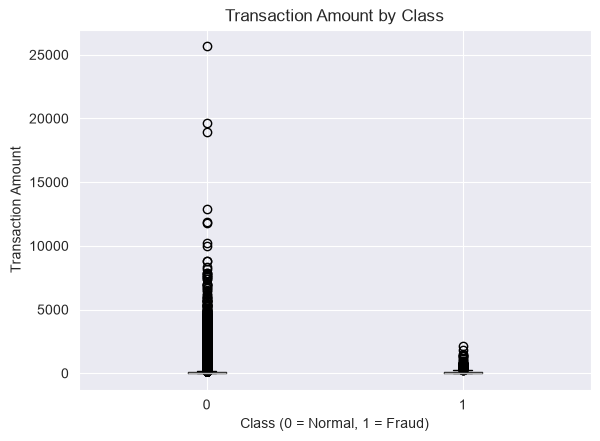

In [8]:
df.boxplot(column='Amount', by='Class')

plt.xlabel('Class (0 = Normal, 1 = Fraud)')
plt.ylabel('Transaction Amount')
plt.title('Transaction Amount by Class')
plt.suptitle('')  # removes pandas automatic title
plt.show()

Fraudulent transactions appear to have a different amount distribution from legitimate transactions. In particular, fraud transactions tend to involve lower amounts, although there is substantial overlap between the classes. Therefore, Amount may provide predictive signal but is unlikely to separate fraud on its own.

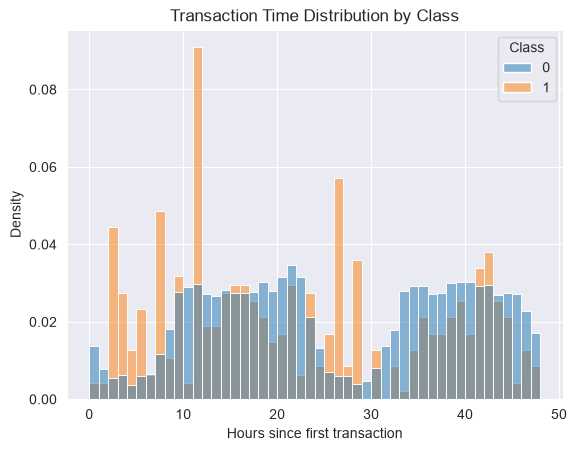

In [9]:
df2 = df.copy()
df2['Hour'] = df2['Time'] / 3600

sns.histplot(
    data=df2,
    x='Hour',
    hue='Class',
    bins=48,
    stat='density',
    common_norm=False
)

plt.xlabel('Hours since first transaction')
plt.ylabel('Density')
plt.title('Transaction Time Distribution by Class')
plt.show()


### Univariate PCA feature analysis

Since the original variables were transformed using PCA, the individual components do not have direct business interpretations. Instead, I compared their distributions between fraudulent and legitimate transactions.

Cohen's d was used as a simple measure of standardized univariate separation. The strongest differences were observed for V17, V14, V12, V10 and V16.

This analysis does not imply that these are necessarily the most important multivariate predictors, because models may capture nonlinear relationships and interactions between features. I will later compare these EDA findings with model-based feature importance.

In [10]:

#1. PCA data and a binary Class column (0 = Non-Fraud, 1 = Fraud)
data = df

# 2. Define a function to calculate Cohen's d effect size
def calculate_cohens_d(group1, group2):
    """Calculates the effect size between two groups."""
    n1, n2 = len(group1), len(group2)
    var1, var2 = np.var(group1, ddof=1), np.var(group2, ddof=1)

    # Calculate pooled standard deviation
    pooled_std = np.sqrt(((n1 - 1) * var1 + (n2 - 1) * var2) / (n1 + n2 - 2))

    # Handle division by zero if both variances are zero
    if pooled_std == 0:
        return 0

    return (np.mean(group1) - np.mean(group2)) / pooled_std

# 3. Compute summaries per feature
summary_list = []
pca_features = [col for col in df.columns if col.startswith('V')]

for col in pca_features:
    fraud = data[data['Class'] == 1][col]
    non_fraud = data[data['Class'] == 0][col]

    # Calculate metrics
    mean_fraud = fraud.mean()
    mean_non_fraud = non_fraud.mean()
    median_fraud = fraud.median()
    median_non_fraud = non_fraud.median()

    mean_diff = mean_fraud - mean_non_fraud
    effect_size = calculate_cohens_d(fraud, non_fraud)

    # Store results
    summary_list.append({
        'Feature': col,
        'Mean_Fraud': mean_fraud,
        'Mean_NonFraud': mean_non_fraud,
        'Median_Fraud': median_fraud,
        'Median_NonFraud': median_non_fraud,
        'Mean_Diff': mean_diff,
        'Cohen_d': effect_size,
        'Abs_Cohen_d': abs(effect_size)  # Useful for sorting
    })

# 4. Convert to DataFrame and sort by the strongest effect size
summary_df = pd.DataFrame(summary_list)
summary_df = summary_df.sort_values(by='Abs_Cohen_d', ascending=False).reset_index(drop=True)

# Display the top 5 features with the highest separation
print(summary_df.head().to_string(index=False))


Feature  Mean_Fraud  Mean_NonFraud  Median_Fraud  Median_NonFraud  Mean_Diff   Cohen_d  Abs_Cohen_d
    V17   -6.463285       0.010963     -5.157596        -0.065096  -6.474249 -8.092438     8.092438
    V14   -6.835946       0.011668     -6.590550         0.051486  -6.847614 -7.522233     7.522233
    V12   -6.103254       0.009476     -5.437354         0.140573  -6.112730 -6.348196     6.348196
    V10   -5.453274       0.007663     -4.466284        -0.092120  -5.460937 -5.185574     5.185574
    V16   -4.000956       0.007845     -3.302899         0.068100  -4.008801 -4.670876     4.670876


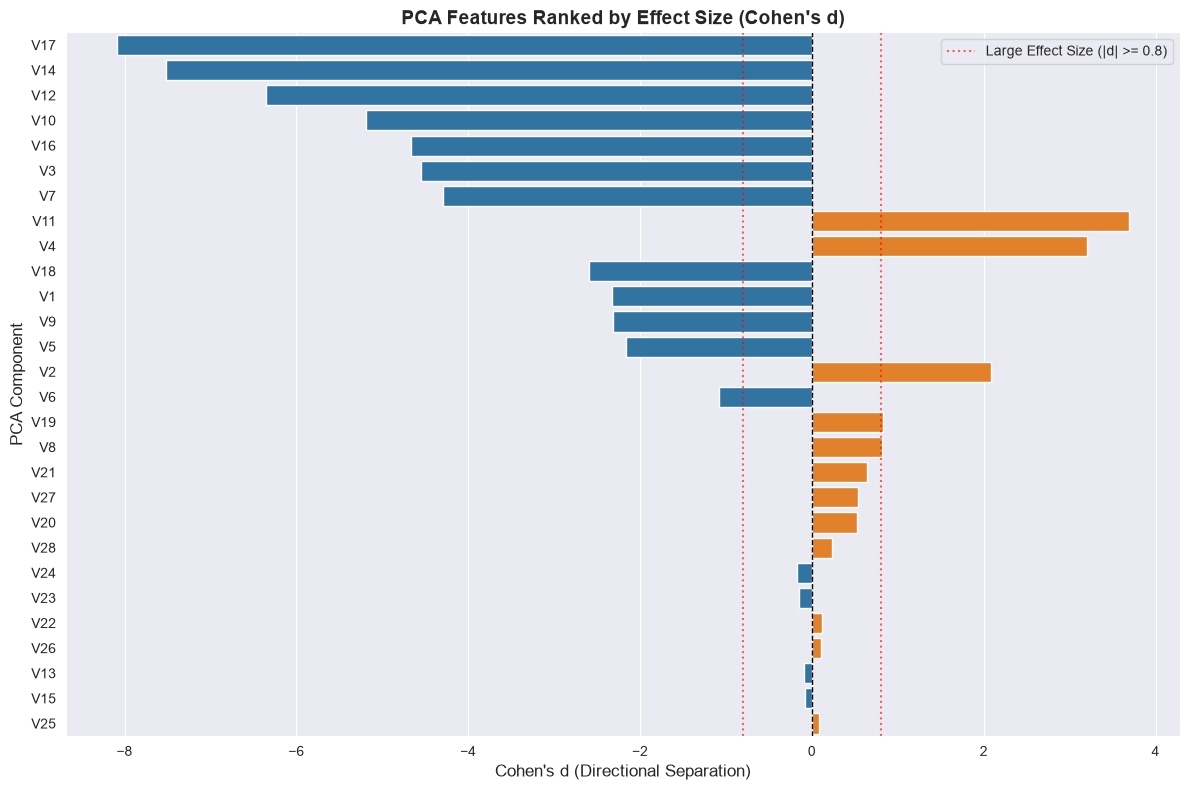

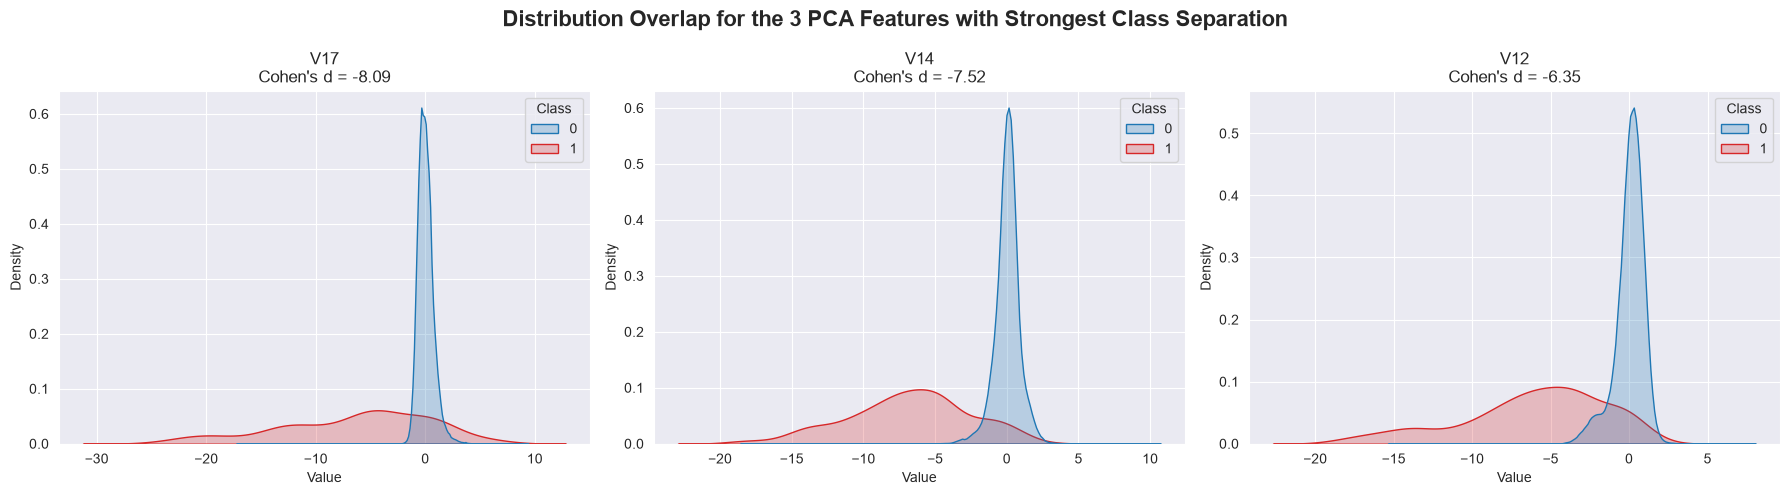

In [11]:
data = df
# ==========================================
# PLOT 1: Overview of All 28 PCA Features
# ==========================================
plt.figure(figsize=(12, 8))
# Color code by the direction of the difference
colors = ['#ff7f0e' if x > 0 else '#1f77b4' for x in summary_df['Cohen_d']]

sns.barplot(
    x='Cohen_d',
    y='Feature',
    data=summary_df,
    palette=colors,
    hue='Feature',
    legend=False
)
plt.axvline(x=0, color='black', linestyle='--', linewidth=1)
plt.axvline(x=0.8, color='red', linestyle=':', alpha=0.6, label='Large Effect Size (|d| >= 0.8)')
plt.axvline(x=-0.8, color='red', linestyle=':', alpha=0.6)

plt.title("PCA Features Ranked by Effect Size (Cohen's d)", fontsize=14, fontweight='bold')
plt.xlabel("Cohen's d (Directional Separation)", fontsize=12)
plt.ylabel("PCA Component", fontsize=12)
plt.legend()
plt.tight_layout()
plt.show()

# ==========================================
# PLOT 2: Distribution of the Top 3 Features
# ==========================================
top_3_features = summary_df['Feature'].head(3).tolist()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle(
    'Distribution Overlap for the 3 PCA Features with Strongest Class Separation',
    fontsize=16,
    fontweight='bold'
)

for i, col in enumerate(top_3_features):
    sns.kdeplot(data=data, x=col, hue='Class', fill=True, common_norm=False, ax=axes[i], palette={0: '#1f77b4', 1: '#d62728'})
    d_val = summary_df.loc[summary_df['Feature'] == col, 'Cohen_d'].values[0]
    axes[i].set_title(f'{col}\nCohen\'s d = {d_val:.2f}', fontsize=12)
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Density')

plt.tight_layout()
plt.show()


## Modeling strategy

The cleaned dataset is split into 64% training, 16% validation, and 20% final test data using stratification to preserve the 0.17% fraud rate. Training data is used for model fitting and hyperparameter tuning, validation data is used for model comparison and threshold selection, and the test set is reserved for final evaluation.

Logistic Regression will serve as a simple linear baseline. Random Forest, XGBoost and LightGBM will then be used to test whether nonlinear relationships and interactions improve performance.

In [12]:
X = df.drop(columns="Class")
y = df["Class"]

# --------------------------------------------------
# Step 1: Hold out the FINAL test set
# --------------------------------------------------

X_dev, X_test, y_dev, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

# --------------------------------------------------
# Step 2: Split development data into train + val
# 20% of 80% = 16% of total dataset
# --------------------------------------------------

X_train, X_val, y_train, y_val = train_test_split(
    X_dev,
    y_dev,
    test_size=0.20,
    stratify=y_dev,
    random_state=42
)

print("Train:", X_train.shape, "Fraud rate:", y_train.mean())
print("Validation:", X_val.shape, "Fraud rate:", y_val.mean())
print("Test:", X_test.shape, "Fraud rate:", y_test.mean())

Train: (181584, 30) Fraud rate: 0.0016631421270596528
Validation: (45396, 30) Fraud rate: 0.001674156313331571
Test: (56746, 30) Fraud rate: 0.0016741268107003137


ROC-AUC is reported for comparability with common fraud-detection benchmarks, but PR-AUC is used as the primary selection metric because the positive class is extremely rare.

In [13]:
def evaluate_classifier(
    model,
    X_eval,
    y_eval,
    model_name="Model",
    class_names=("Legit", "Fraud"),
    summary_flag=True
):
    """
    Evaluate a binary classification model.

    Produces:
    1. Confusion matrix
    2. Normalized confusion matrix
    3. Classification report
    4. Precision-Recall curve
    5. PR-AUC and ROC-AUC

    Returns:
        DataFrame with main fraud-class metrics.
    """

    # Predictions
    y_pred = model.predict(X_eval)
    y_prob = model.predict_proba(X_eval)[:, 1]

    # Confusion matrix
    cm = confusion_matrix(
        y_eval,
        y_pred
    )

    if not summary_flag:
        disp = ConfusionMatrixDisplay(
            confusion_matrix=cm,
            display_labels=class_names
        )

        disp.plot(values_format="d")
        plt.title(f"{model_name} - Confusion Matrix")
        plt.show()

    # Normalized confusion matrix
    cm_normalized = confusion_matrix(
        y_eval,
        y_pred,
        normalize="true"
    )

    if not summary_flag:
        disp_normalized = ConfusionMatrixDisplay(
            confusion_matrix=cm_normalized,
            display_labels=class_names
        )

        disp_normalized.plot(values_format=".2f")
        plt.title(f"{model_name} - Normalized Confusion Matrix")
        plt.show()

    # Classification report
    report = classification_report(
        y_eval,
        y_pred,
        output_dict=True,
        zero_division=0
    )

    report_df = pd.DataFrame(
        report
    ).transpose().round(3)

    if not summary_flag:

        fig, ax = plt.subplots(figsize=(9, 4))
        ax.axis("off")

        table = ax.table(
            cellText=report_df.values,
            rowLabels=report_df.index,
            colLabels=report_df.columns,
            loc="center"
        )

        table.auto_set_font_size(False)
        table.set_fontsize(10)
        table.scale(1, 1.5)

        plt.title(
            f"{model_name} - Classification Report"
        )

        plt.tight_layout()
        plt.show()

    # Precision-Recall curve
    precision, recall, _ = precision_recall_curve(
        y_eval,
        y_prob
    )

    pr_auc = average_precision_score(
        y_eval,
        y_prob
    )

    roc_auc = roc_auc_score(
        y_eval,
        y_prob
    )

    if not summary_flag:

        plt.figure(figsize=(7, 5))

        plt.plot(
            recall,
            precision
        )

        plt.xlabel("Recall")
        plt.ylabel("Precision")

        plt.title(
            f"{model_name} - Precision-Recall Curve\n"
            f"PR-AUC = {pr_auc:.3f}"
        )

        plt.show()

    # Fraud-class metrics
    fraud_metrics = report["1"]

    results_df = pd.DataFrame({
        "Model": [model_name],
        "Precision": [fraud_metrics["precision"]],
        "Recall": [fraud_metrics["recall"]],
        "F1": [fraud_metrics["f1-score"]],
        "PR-AUC": [pr_auc],
        "ROC-AUC": [roc_auc]
    }).round(3)

    if summary_flag:
        print("\nSummary:")
        print(results_df)

    return results_df

### Logistic Regression baseline

The baseline Logistic Regression achieved:

- Precision: 0.912
- Recall: 0.684
- F1-score: 0.782
- PR-AUC: 0.823
- ROC-AUC: 0.968

The model is relatively conservative: when it predicts fraud, it is usually correct, but it misses approximately one-third of fraudulent transactions.

I also tested `class_weight="balanced"` to increase the importance of the minority fraud class. This substantially increased recall to 0.895, but precision fell to only 0.054 and F1-score dropped to 0.102.

This demonstrates that automatic class balancing is not necessarily beneficial. In this case, improving recall came at the cost of a very large number of false-positive fraud alerts.

Therefore, the unweighted Logistic Regression is retained as the linear baseline.

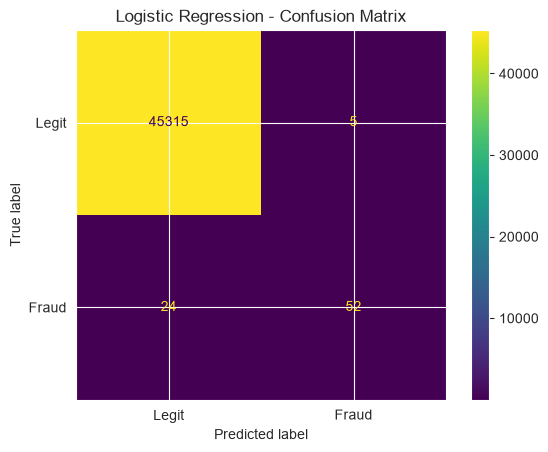

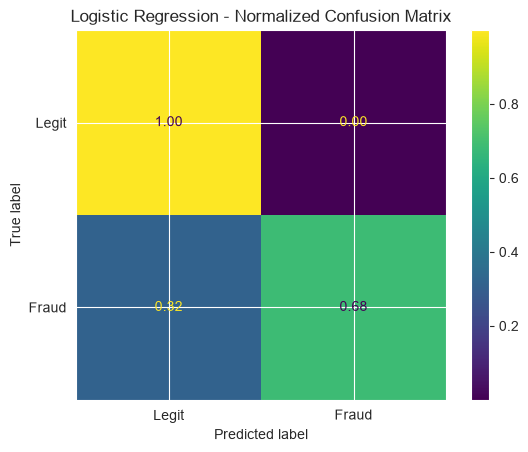

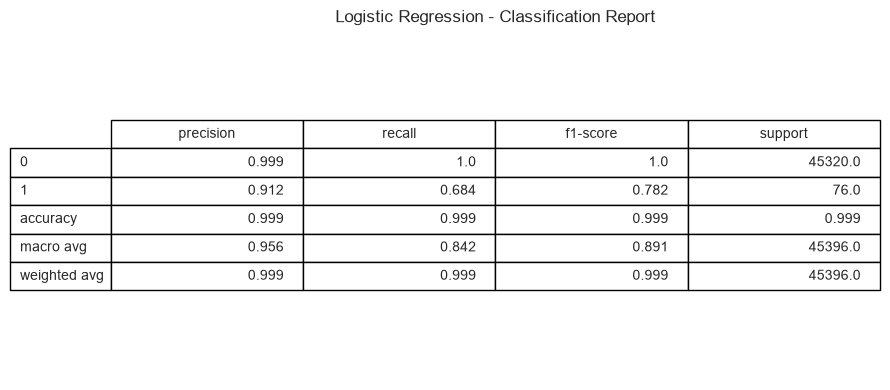

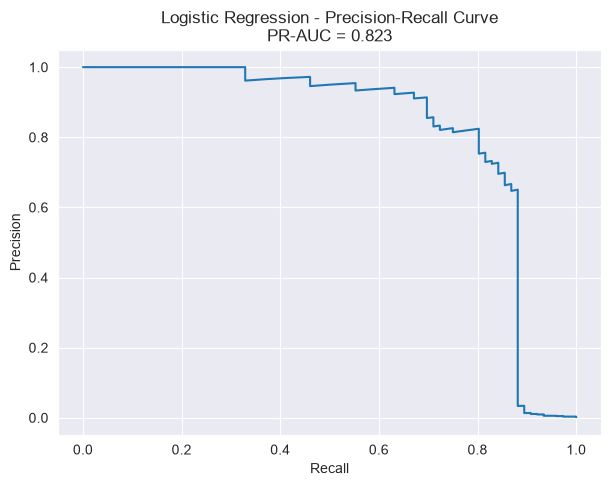


Summary:
                            Model  Precision  Recall     F1  PR-AUC  ROC-AUC
0  Logistic Regression - Balanced      0.054   0.895  0.102   0.814    0.975


In [14]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

# The scaler is fitted only on the training data to avoid data leakage.
logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

logistic_model.fit(X_train_scaled, y_train)

baseline_results = evaluate_classifier(
    logistic_model,
    X_val_scaled,
    y_val,
    model_name="Logistic Regression",
    summary_flag=False
)

balanced_logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=42,
    class_weight="balanced"
)

balanced_logistic_model.fit(
    X_train_scaled,
    y_train
)

balanced_results = evaluate_classifier(
    balanced_logistic_model,
    X_val_scaled,
    y_val,
    model_name="Logistic Regression - Balanced",
    summary_flag=True
)

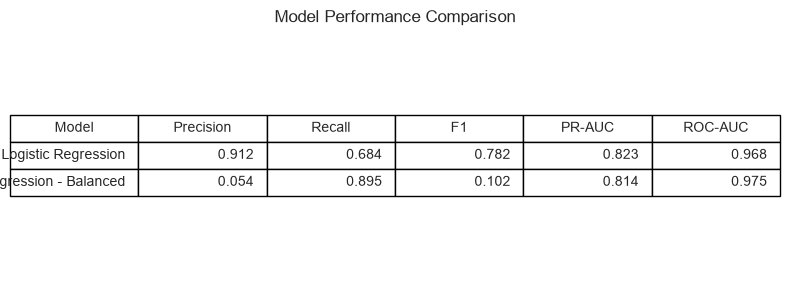

In [15]:
def plot_table(df, title="Model Comparison", figsize=(8, 3)):
    fig, ax = plt.subplots(figsize=figsize)
    ax.axis("off")

    table = ax.table(
        cellText=df.values,
        colLabels=df.columns,
        loc="center"
    )

    table.auto_set_font_size(False)
    table.set_fontsize(10)
    table.scale(1, 1.5)

    plt.title(title)
    plt.tight_layout()
    plt.show()


comparison_df = pd.concat(
    [baseline_results, balanced_results],
    ignore_index=True
)

plot_table(
    comparison_df,
    title="Model Performance Comparison"
)

## Nonlinear tree-based models

Logistic Regression assumes a relatively simple linear relationship between the predictors and the log-odds of fraud.

To capture nonlinear thresholds and interactions between PCA components, I next evaluate ensemble tree models:

Random Forest: trains many independent decision trees and averages their predictions.
XGBoost: builds trees sequentially, with each new tree correcting errors made by the current ensemble.

Tree-based models do not require feature standardization, so the original features are used.

In [16]:
# -------------------------
# Random Forest
# -------------------------

random_forest = RandomForestClassifier(
    random_state=42,
    n_jobs=4
)

random_forest.fit(X_train, y_train)

rf_results = evaluate_classifier(
    random_forest,
    X_val,
    y_val,
    model_name="Random Forest",
    summary_flag = True
)


Summary:
           Model  Precision  Recall     F1  PR-AUC  ROC-AUC
0  Random Forest      0.955   0.842  0.895   0.867    0.939


XGBoost with hyperparameter tuning

Because XGBoost has many interacting hyperparameters, exhaustive grid search would require an impractically large number of combinations. I therefore used RandomizedSearchCV, which samples candidate combinations from predefined distributions.

Hyperparameters were selected using stratified cross-validation and average_precision (PR-AUC) as the optimization metric because of the severe class imbalance.

Parameters explored include tree complexity, learning rate, number of trees, regularization, subsampling, and scale_pos_weight.

In [17]:
# -------------------------
# XGBoost hyperparameter tuning
# -------------------------

xgb = XGBClassifier(
    objective="binary:logistic",
    eval_metric="aucpr",
    random_state=42,
    n_jobs=1
)

param_distributions = {

    # Number of trees
    "n_estimators": randint(100, 800),

    # Contribution of each new tree
    "learning_rate": loguniform(0.01, 0.3),

    # Tree complexity
    "max_depth": randint(2, 8),

    # Minimum weight required to create another split
    "min_child_weight": randint(1, 10),

    # Fraction of observations used by each tree
    "subsample": uniform(0.6, 0.4),

    # Fraction of features used by each tree
    "colsample_bytree": uniform(0.6, 0.4),

    # Minimum improvement needed to make another split
    "gamma": uniform(0, 5),

    # L1 regularization
    "reg_alpha": loguniform(1e-4, 2),

    # L2 regularization
    "reg_lambda": loguniform(0.1, 10),

    # Relative importance of fraud observations
    "scale_pos_weight": loguniform(1, 100)
}

cv = StratifiedKFold(
    n_splits=3,
    shuffle=True,
    random_state=42
)

random_search = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=param_distributions,

    n_iter=50,                 # try 50 parameter combinations

    scoring="average_precision",

    cv=cv,

    n_jobs=-1,                 # parallelize the search

    verbose=2,

    random_state=42,

    return_train_score=True
)

random_search.fit(
    X_train,
    y_train
)

print("Best CV PR-AUC:")
print(random_search.best_score_)

print("\nBest parameters:")
print(random_search.best_params_)

best_xgb = random_search.best_estimator_

print(best_xgb)

Fitting 3 folds for each of 50 candidates, totalling 150 fits
Best CV PR-AUC:
0.8423705461580974

Best parameters:
{'colsample_bytree': np.float64(0.695824756266789), 'gamma': np.float64(0.7244743604561155), 'learning_rate': np.float64(0.052842222499425995), 'max_depth': 7, 'min_child_weight': 7, 'n_estimators': 538, 'reg_alpha': np.float64(0.1886899679947144), 'reg_lambda': np.float64(0.2987274199563841), 'scale_pos_weight': np.float64(28.604390429824615), 'subsample': np.float64(0.7471132530877013)}
XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=np.float64(0.695824756266789), device=None,
              early_stopping_rounds=None, enable_categorical=True,
              eval_metric='aucpr', feature_types=None, feature_weights=None,
              gamma=np.float64(0.7244743604561155), grow_policy=None,
              importance_type=None, interaction_constraints=None,
              le

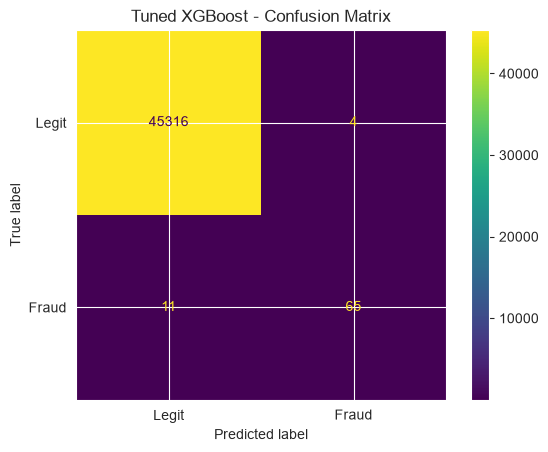

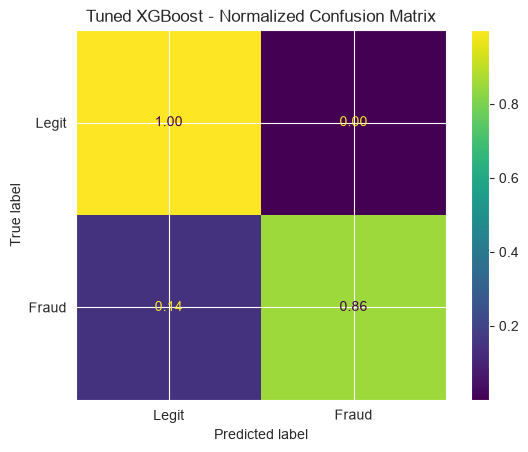

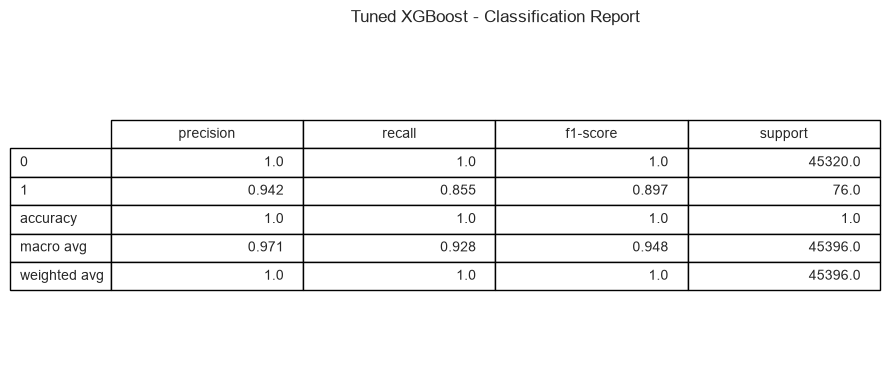

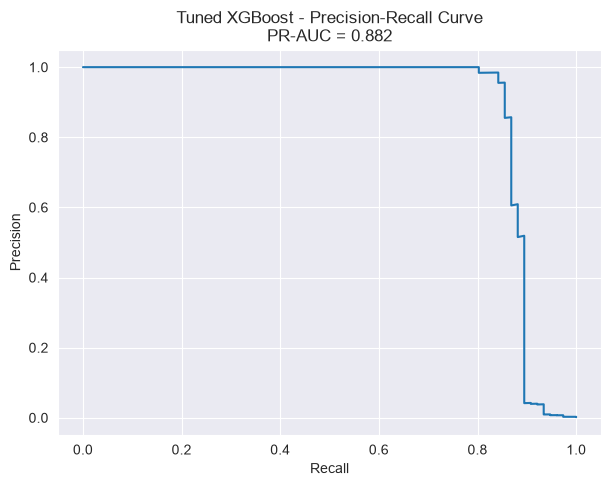

In [18]:
xgb_tuned_results = evaluate_classifier(
    best_xgb,
    X_val,
    y_val,
    model_name="Tuned XGBoost",
    summary_flag = False
)

### XGBoost tuning results

Hyperparameter optimization substantially improved XGBoost performance.

On the validation set, tuned XGBoost achieved:

- Precision: 0.942
- Recall: 0.855
- F1-score: 0.897
- PR-AUC: 0.882
- ROC-AUC: 0.974

Compared with Random Forest, tuned XGBoost achieved higher recall, slightly higher F1-score, and higher PR-AUC, while maintaining similarly high precision.

Because the difference between the strongest tree-based models is relatively small, cross-validation is used next to determine whether this advantage is stable across different subsets of the training data.

## LightGBM

LightGBM is another gradient-boosted decision-tree algorithm. Unlike the typical level-wise tree growth used by XGBoost, LightGBM uses a leaf-wise growth strategy.

This can make LightGBM computationally efficient and highly expressive, but also more sensitive to parameters controlling tree complexity.

I first evaluate the default classifier before tuning its hyperparameters.

In [19]:
lgbm_model = LGBMClassifier(
    objective="binary",
    random_state=42,
    n_jobs=-1,
    verbosity=-1
)

lgbm_model.fit(
    X_train,
    y_train
)

lgbm_results = evaluate_classifier(
    lgbm_model,
    X_val,
    y_val,
    model_name="LightGBM",
    summary_flag = True
)


Summary:
      Model  Precision  Recall     F1  PR-AUC  ROC-AUC
0  LightGBM      0.287   0.566  0.381   0.229    0.745


Because LightGBM is particularly sensitive to parameters such as num_leaves, min_child_samples, learning rate and class weighting, I applied randomized hyperparameter optimization using the same PR-AUC objective used for XGBoost.

In [20]:
# Lets try to improve this model

cv = StratifiedKFold(
    n_splits=7,
    shuffle=True,
    random_state=42
)

lgbm_cv_scores = cross_val_score(
    lgbm_model,
    X_train,
    y_train,
    scoring="average_precision",
    cv=cv,
    n_jobs=-4
)

print("LightGBM:")
print("Scores:", lgbm_cv_scores)
print("Mean PR-AUC:", lgbm_cv_scores.mean())
print("Std:", lgbm_cv_scores.std())

LightGBM:
Scores: [0.10576766 0.31465185 0.65428606 0.51097925 0.36072834 0.50499741
 0.48209747]
Mean PR-AUC: 0.41907257828946554
Std: 0.16370493685758641


In [21]:
# ----------------------------------------
# Base LightGBM model
# ----------------------------------------

lgbm = LGBMClassifier(
    objective="binary",
    random_state=42,
    n_jobs=1,
    verbosity=-1
)

# ----------------------------------------
# Parameter search space
# ----------------------------------------

param_distributions = {

    # How many boosting trees
    "n_estimators": randint(200, 1200),

    # Contribution of each tree
    "learning_rate": loguniform(0.01, 0.2),

    # Very important in LightGBM:
    # controls tree complexity
    "num_leaves": randint(10, 100),

    # Limit depth to avoid very complex trees
    "max_depth": randint(3, 12),

    # Minimum observations required in a leaf
    # crucial for preventing overfitting
    "min_child_samples": randint(10, 150),

    # Fraction of rows used
    "subsample": uniform(0.6, 0.4),

    # Fraction of features used
    "colsample_bytree": uniform(0.6, 0.4),

    # Regularization
    "reg_alpha": loguniform(1e-4, 10),
    "reg_lambda": loguniform(1e-4, 10),

    # Imbalance handling
    "scale_pos_weight": loguniform(1, 100)
}

In [22]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

lgbm_search = RandomizedSearchCV(
    estimator=lgbm,
    param_distributions=param_distributions,

    n_iter=60,

    scoring="average_precision",

    cv=cv,

    n_jobs=-1,
    verbose=2,

    random_state=42,

    return_train_score=True
)

lgbm_search.fit(
    X_train,
    y_train
)

Fitting 5 folds for each of 60 candidates, totalling 300 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",LGBMClassifie... verbosity=-1)
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'colsample_bytree': <scipy.stats....0017800F432F0>, 'learning_rate': <scipy.stats....0017800F40200>, 'max_depth': <scipy.stats....0017800E99790>, 'min_child_samples': <scipy.stats....0017800E50CE0>, ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",60
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'average_precision'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"verbose verbose: int, default = 0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",2
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"return_train_score return_train_score: bool, default=FalseIf ``False``, the ``cv_results_`` attribute will not include trainingscores.Computing training scores is used to get insights on how differentparameter settings impact the overfitting/underfitting trade-off.However computing the scores on 

In [23]:
print("Best CV PR-AUC:")
print(lgbm_search.best_score_)

print("\nBest parameters:")
print(lgbm_search.best_params_)

best_lgbm = lgbm_search.best_estimator_

Best CV PR-AUC:
0.8415998571477628

Best parameters:
{'colsample_bytree': np.float64(0.9730913933416053), 'learning_rate': np.float64(0.1338983108665715), 'max_depth': 7, 'min_child_samples': 128, 'n_estimators': 1000, 'num_leaves': 74, 'reg_alpha': np.float64(0.02522611721212304), 'reg_lambda': np.float64(8.441706591995112), 'scale_pos_weight': np.float64(5.668627768197328), 'subsample': np.float64(0.8998313199904289)}


In [24]:
lgbm_tuned_results = evaluate_classifier(
    best_lgbm,
    X_val,
    y_val,
    model_name="Tuned LightGBM",
     summary_flag = True
)

lgbm_cv_scores = cross_val_score(
    best_lgbm,
    X_train,
    y_train,
    scoring="average_precision",
    cv=cv,
    n_jobs=-1
)

print("LightGBM:")
print("Scores:", lgbm_cv_scores)
print("Mean PR-AUC:", lgbm_cv_scores.mean())
print("Std:", lgbm_cv_scores.std())


Summary:
            Model  Precision  Recall     F1  PR-AUC  ROC-AUC
0  Tuned LightGBM      0.942   0.855  0.897    0.88     0.97
LightGBM:
Scores: [0.84361861 0.86535405 0.81790962 0.79972723 0.88138978]
Mean PR-AUC: 0.8415998571477628
Std: 0.029886847536758337


### LightGBM tuning results

The default LightGBM configuration performed poorly on this dataset, with a validation PR-AUC of approximately 0.229 and highly unstable cross-validation performance.

After hyperparameter optimization, performance improved substantially:

- Validation Precision: 0.942
- Validation Recall: 0.855
- Validation F1-score: 0.897
- Validation PR-AUC: 0.880
- Validation ROC-AUC: 0.970
- Mean CV PR-AUC: approximately 0.842 ± 0.030

This demonstrates that the poor default performance was primarily a configuration issue rather than evidence that LightGBM was unsuitable for the problem. After tuning, LightGBM became highly competitive with XGBoost.

In [25]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

models = {
    "Random Forest": random_forest,
    "Tuned XGBoost": best_xgb,
    "Tuned LightGBM": best_lgbm
}

cv_results = []

for model_name, classifier in models.items():

    scores = cross_val_score(
        classifier,
        X_train,
        y_train,
        scoring="average_precision",
        cv=cv,
        n_jobs=-1
    )

    cv_results.append({
        "Model": model_name,
        "Mean PR-AUC": scores.mean(),
        "Std PR-AUC": scores.std(),
        "Min PR-AUC": scores.min(),
        "Max PR-AUC": scores.max()
    })

cv_summary = pd.DataFrame(cv_results)

cv_summary

,Model,Mean PR-AUC,Std PR-AUC,Min PR-AUC,Max PR-AUC
0,Random Forest,0.822929,0.039814,0.758668,0.865329
1,Tuned XGBoost,0.845977,0.023548,0.810809,0.878137
2,Tuned LightGBM,0.841600,0.029887,0.799727,0.881390


### Cross-validation comparison

Five-fold stratified cross-validation was used to compare the strongest tree-based models using PR-AUC.

The mean cross-validated PR-AUC scores were approximately:

- Random Forest: 0.823 ± 0.040
- Tuned XGBoost: 0.846 ± 0.024
- Tuned LightGBM: 0.842 ± 0.030

Tuned XGBoost achieved the highest mean PR-AUC and showed relatively low variability across folds. Tuned LightGBM performed very similarly, while Random Forest had a somewhat lower mean score and greater variability.

The difference between XGBoost and LightGBM is small, so XGBoost should not be interpreted as dramatically superior. However, its combination of the highest mean cross-validation PR-AUC, strong validation performance, and relatively stable fold-to-fold performance makes it the preferred candidate for final threshold optimization.

## Feature importance

To examine whether the variables identified during EDA are also used prominently by the fitted models, model-specific feature-importance measures are compared.

For Logistic Regression, the absolute values of coefficients from the standardized model are used.

For Random Forest, XGBoost, and LightGBM, each model's built-in tree-based feature-importance measure is used.

Because these importance definitions are not directly comparable across model families, the analysis focuses on feature rankings and whether the same predictors consistently appear among the most important features.

In [26]:
def get_feature_importance(cur_model, feature_names, model_type):
    """
    Return feature importance for a fitted model.

    model_type:
        'logistic' -> absolute standardized coefficients
        'tree'     -> feature_importances_
    """

    if model_type == "logistic":
        importance = np.abs(cur_model.coef_[0])

    elif model_type == "tree":
        importance = cur_model.feature_importances_

    else:
        raise ValueError("model_type must be 'logistic' or 'tree'")

    importance_df = pd.DataFrame({
        "Feature": feature_names,
        "Importance": importance
    })

    return importance_df.sort_values(
        "Importance",
        ascending=False
    ).reset_index(drop=True)

In [27]:
lr_importance = get_feature_importance(
    logistic_model,
    X_train.columns,
    model_type="logistic"
)

rf_importance = get_feature_importance(
    random_forest,
    X_train.columns,
    model_type="tree"
)

xgb_importance = get_feature_importance(
    best_xgb,
    X_train.columns,
    model_type="tree"
)

lgbm_importance = get_feature_importance(
    best_lgbm,
    X_train.columns,
    model_type="tree"
)

In [28]:
def compare_top_features(importance_dict, top_n=10):

    comparison = {}

    for model_name, importance_df in importance_dict.items():

        comparison[model_name] = (
            importance_df
            .head(top_n)["Feature"]
            .reset_index(drop=True)
        )

    comparison_df = pd.DataFrame(comparison)

    # Rank starts at 1 instead of 0
    comparison_df.index += 1
    comparison_df.index.name = "Rank"

    return comparison_df

In [29]:
importance_models = {
    "Logistic Regression": lr_importance,
    "Random Forest": rf_importance,
    "XGBoost": xgb_importance,
    "LightGBM": lgbm_importance
}

feature_comparison = compare_top_features(
    importance_models,
    top_n=10
)

feature_comparison

,Logistic Regression,Random Forest,XGBoost,LightGBM
Rank,,,,
1,V4,V17,V14,Time
2,V14,V14,V10,V26
3,V10,V12,V12,V13
4,V22,V10,V17,Amount
5,V9,V16,V4,V12
6,V15,V11,V3,V22
7,V21,V7,V16,V24
8,V27,V9,V20,V1
9,V20,V18,V11,V19


In [30]:
eda_features = {
    "V17",
    "V14",
    "V12",
    "V10",
    "V16"
}

In [31]:
def compare_with_eda(
    importance_dict,
    eda_features,
    top_n=10
):

    rows = []

    for model_name, importance_df in importance_dict.items():

        top_features = set(
            importance_df.head(top_n)["Feature"]
        )

        overlap = top_features.intersection(
            eda_features
        )

        rows.append({
            "Model": model_name,
            "EDA Features in Top 10": len(overlap),
            "Overlapping Features": ", ".join(
                sorted(overlap)
            )
        })

    return pd.DataFrame(rows)

In [32]:
eda_comparison = compare_with_eda(
    importance_models,
    eda_features,
    top_n=10
)

eda_comparison

,Model,EDA Features in Top 10,Overlapping Features
0,Logistic Regression,2,"V10, V14"
1,Random Forest,5,"V10, V12, V14, V16, V17"
2,XGBoost,5,"V10, V12, V14, V16, V17"
3,LightGBM,1,V12


### Relationship between EDA and model feature importance

The univariate EDA identified `V10`, `V12`, `V14`, `V16`, and `V17` as the PCA components showing the strongest separation between fraudulent and legitimate transactions.

All five of these features appeared among the top 10 predictors for both Random Forest and XGBoost. Logistic Regression included two (`V10` and `V14`), while LightGBM included only one (`V12`).

This supports the predictive relevance of the features identified during EDA, particularly for Random Forest and XGBoost. However, the rankings do not need to agree across algorithms. EDA evaluates each variable independently, while fitted models assess predictors jointly and may capture nonlinear relationships, interactions, and redundancy between variables.

In [33]:
def plot_feature_consensus(
    importance_dict,
    top_n=10
):

    all_top_features = []

    for importance_df in importance_dict.values():

        all_top_features.extend(
            importance_df
            .head(top_n)["Feature"]
            .tolist()
        )

    feature_counts = (
        pd.Series(all_top_features)
        .value_counts()
        .sort_values()
    )

    plt.figure(figsize=(8, 6))

    plt.barh(
        feature_counts.index,
        feature_counts.values
    )

    plt.xlabel("Number of Models")
    plt.ylabel("Feature")
    plt.title(
        f"Feature Importance Consensus Across Models\n"
        f"(Appearance in Top {top_n})"
    )

    plt.xticks(
        range(
            1,
            len(importance_dict) + 1
        )
    )

    plt.tight_layout()
    plt.show()

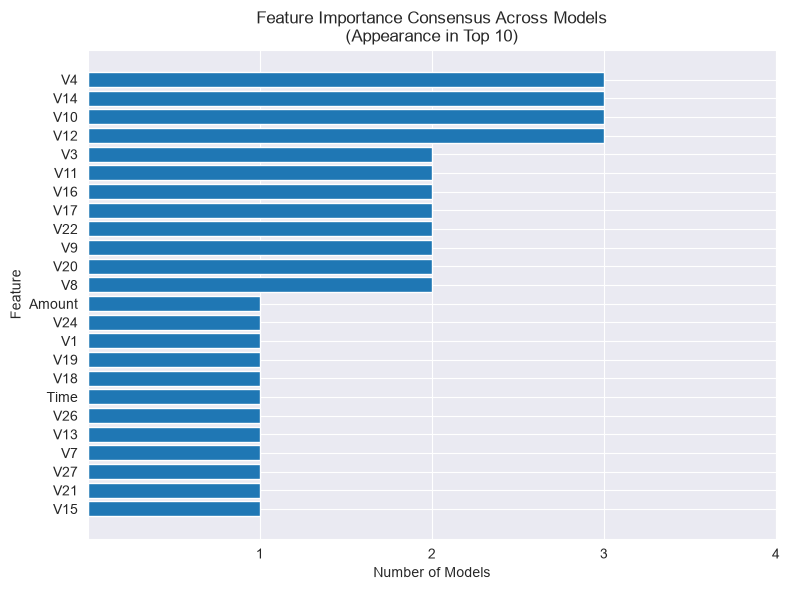

In [34]:
plot_feature_consensus(
    importance_models,
    top_n=10
)

Feature importance comparison: Several variables identified as having strong univariate separation during EDA also appear among the most important predictors in the fitted models. However, the rankings differ between algorithms because EDA measures each variable independently, whereas model importance reflects how variables contribute jointly and can account for nonlinear relationships and interactions.
Raw importance values are not compared directly across model families because Logistic Regression coefficients and tree-based feature-importance measures have different meanings. The comparison therefore focuses on feature rankings and cross-model agreement rather than absolute importance magnitudes.


## Classification threshold optimization

Classification models produce a probability score that must be converted into a binary prediction using a decision threshold.

The conventional threshold of 0.5 is not necessarily optimal for fraud detection, particularly under severe class imbalance.

Lower thresholds generally increase recall but may reduce precision, while higher thresholds generally increase precision at the cost of recall.

Threshold selection is therefore performed exclusively on the dedicated validation set. The final test set is not used during threshold optimization.

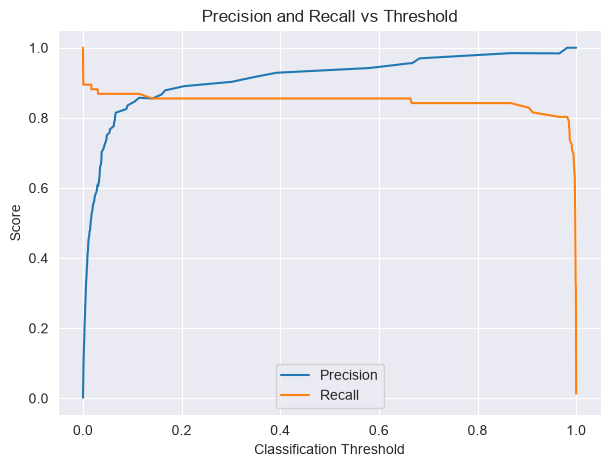

In [35]:
# --------------------------------------------------
# Threshold optimization using VALIDATION set
# --------------------------------------------------
threshold_model = clone(best_xgb)

# Fit only on training data
threshold_model.fit(X_train, y_train)

# Predict probabilities on validation data
y_val_prob = threshold_model.predict_proba(X_val)[:, 1]

# Precision-recall values across possible thresholds
precision, recall, thresholds = precision_recall_curve(
    y_val,
    y_val_prob
)

# Plot threshold vs precision / recall
plt.figure(figsize=(7, 5))

plt.plot(
    thresholds,
    precision[:-1],
    label="Precision"
)

plt.plot(
    thresholds,
    recall[:-1],
    label="Recall"
)

plt.xlabel("Classification Threshold")
plt.ylabel("Score")
plt.title("Precision and Recall vs Threshold")
plt.legend()

plt.show()

In [36]:
def evaluate_thresholds(y_true, y_prob):

    thresholds = np.arange(0.01, 1.00, 0.01)

    results = []

    for threshold in thresholds:

        y_pred = (y_prob >= threshold).astype(int)

        precision = precision_score(
            y_true,
            y_pred,
            zero_division=0
        )

        recall = recall_score(
            y_true,
            y_pred,
            zero_division=0
        )

        f1 = f1_score(
            y_true,
            y_pred,
            zero_division=0
        )

        tn, fp, fn, tp = confusion_matrix(
            y_true,
            y_pred
        ).ravel()

        results.append({
            "Threshold": threshold,
            "Precision": precision,
            "Recall": recall,
            "F1": f1,
            "TP": tp,
            "FP": fp,
            "FN": fn,
            "TN": tn
        })

    return pd.DataFrame(results)

In [37]:
threshold_results = evaluate_thresholds(
    y_val,
    y_val_prob
)

In [38]:
best_row = threshold_results.loc[
    threshold_results["F1"].idxmax()
]

print(best_row)

Threshold        0.690000
Precision        0.984615
Recall           0.842105
F1               0.907801
TP              64.000000
FP               1.000000
FN              12.000000
TN           45319.000000
Name: 68, dtype: float64


In [39]:
best_threshold = best_row["Threshold"]

print("Best threshold:", best_threshold)

Best threshold: 0.6900000000000001


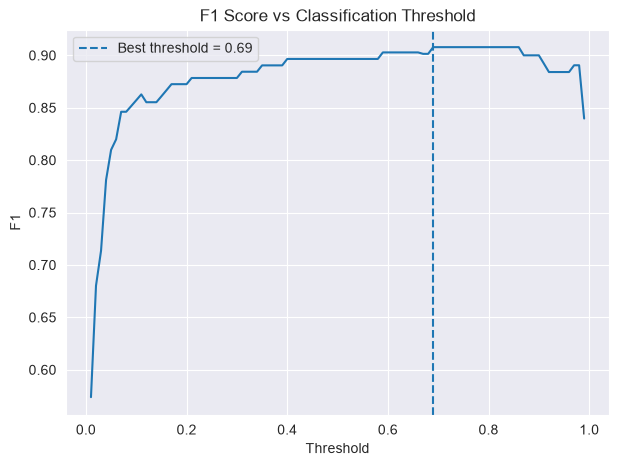

In [40]:
plt.figure(figsize=(7, 5))

plt.plot(
    threshold_results["Threshold"],
    threshold_results["F1"]
)

plt.axvline(
    best_threshold,
    linestyle="--",
    label=f"Best threshold = {best_threshold:.2f}"
)

plt.xlabel("Threshold")
plt.ylabel("F1")
plt.title("F1 Score vs Classification Threshold")
plt.legend()

plt.show()

In [41]:
def compare_threshold_strategies(
    y_true,
    y_prob,
    threshold_results,
    min_recall=0.90,
    min_precision=0.90,
    all_flag = False
):

    # -----------------------------
    # 1. Choose the 3 thresholds
    # -----------------------------

    # A. Maximum F1
    best_f1_row = threshold_results.loc[
        threshold_results["F1"].idxmax()
    ]

    # B. Best precision while recall >= target
    recall_candidates = threshold_results[
        threshold_results["Recall"] >= min_recall
    ]

    best_recall_row = recall_candidates.loc[
        recall_candidates["Precision"].idxmax()
    ]

    # C. Best recall while precision >= target
    precision_candidates = threshold_results[
        threshold_results["Precision"] >= min_precision
    ]

    best_precision_row = precision_candidates.loc[
        precision_candidates["Recall"].idxmax()
    ]


    strategies = {
        "Max F1": best_f1_row["Threshold"],

        f"Best Precision\nRecall ≥ {min_recall:.0%}":
            best_recall_row["Threshold"],

        f"Best Recall\nPrecision ≥ {min_precision:.0%}":
            best_precision_row["Threshold"]
    }


    summary_rows = []


    # -----------------------------
    # 2. Evaluate every strategy
    # -----------------------------

    for name, threshold in strategies.items():

        y_pred = (y_prob >= threshold).astype(int)

        precision = precision_score(
            y_true,
            y_pred,
            zero_division=0
        )

        recall = recall_score(
            y_true,
            y_pred,
            zero_division=0
        )

        f1 = f1_score(
            y_true,
            y_pred,
            zero_division=0
        )

        tn, fp, fn, tp = confusion_matrix(
            y_true,
            y_pred
        ).ravel()


        # -------------------------
        # Summary row
        # -------------------------

        summary_rows.append({
            "Strategy": name.replace("\n", " "),
            "Threshold": round(threshold, 3),
            "Precision": round(precision, 3),
            "Recall": round(recall, 3),
            "F1": round(f1, 3),
            "TP": tp,
            "FP": fp,
            "FN": fn,
            "TN": tn
        })


        # -------------------------
        # Confusion Matrix
        # -------------------------

        cm = confusion_matrix(
            y_true,
            y_pred
        )

        disp = ConfusionMatrixDisplay(
            confusion_matrix=cm,
            display_labels=["Legit", "Fraud"]
        )

        if all_flag:
            disp.plot(values_format="d")

            plt.title(
                f"{name}\n"
                f"Threshold = {threshold:.3f}"
            )

            plt.show()


        # -------------------------
        # Classification Report
        # -------------------------

        report = classification_report(
            y_true,
            y_pred,
            target_names=["Legit", "Fraud"],
            output_dict=True,
            zero_division=0
        )

        report_df = (
            pd.DataFrame(report)
            .transpose()
            .round(3)
        )
        if all_flag:
            fig, ax = plt.subplots(figsize=(8, 3.5))
            ax.axis("off")

            table = ax.table(
                cellText=report_df.values,
                colLabels=report_df.columns,
                rowLabels=report_df.index,
                loc="center"
            )

            table.auto_set_font_size(False)
            table.set_fontsize(10)
            table.scale(1, 1.4)

            plt.title(
                f"{name} - Classification Report\n"
                f"Threshold = {threshold:.3f}"
            )

            plt.tight_layout()
            plt.show()


    # -----------------------------
    # 3. Final comparison table
    # -----------------------------

    summary_df = pd.DataFrame(summary_rows)

    return summary_df

In [42]:
threshold_summary = compare_threshold_strategies(
    y_val,
    y_val_prob,
    threshold_results,
    min_recall=0.85,
    min_precision=0.90,
    all_flag = False
)

threshold_summary

,Strategy,Threshold,Precision,Recall,F1,TP,FP,FN,TN
0,Max F1,0.69,0.985,0.842,0.908,64,1,12,45319
1,Best Precision Recall ≥ 85%,0.59,0.956,0.855,0.903,65,3,11,45317
2,Best Recall Precision ≥ 90%,0.21,0.903,0.855,0.878,65,7,11,45313


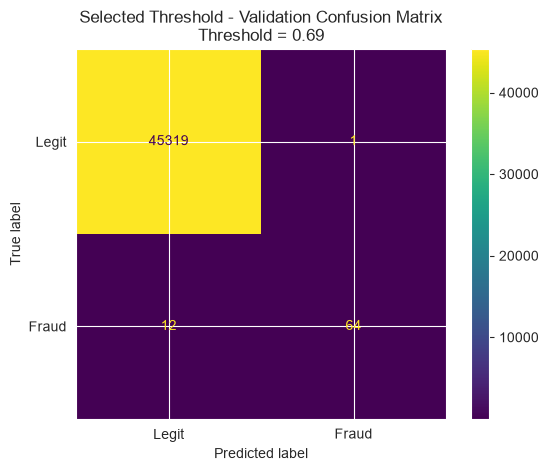

In [43]:
# Confusion matrix for the threshold selected on the validation set

y_pred_selected = (
    y_val_prob >= best_threshold
).astype(int)

cm = confusion_matrix(
    y_val,
    y_pred_selected
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Legit", "Fraud"]
)

disp.plot(values_format="d")

plt.title(
    f"Selected Threshold - Validation Confusion Matrix\n"
    f"Threshold = {best_threshold:.2f}"
)

plt.show()

### Final threshold selection

Threshold optimization was performed exclusively on the validation set.

Three operating strategies were considered:

- Maximum F1: threshold = 0.69, precision = 0.985, recall = 0.842, F1 = 0.908
- Maximum precision while maintaining recall ≥ 85%: threshold = 0.59, precision = 0.956, recall = 0.855, F1 = 0.903
- Maximum recall while maintaining precision ≥ 90%: threshold = 0.21, precision = 0.903, recall = 0.855, F1 = 0.878

The recall difference between thresholds 0.59 and 0.21 is zero, while the lower threshold generates additional false positives. The maximum-F1 threshold of 0.69 sacrifices one additional detected fraud case on the validation set but reduces false positives to only one.

In the absence of an explicit business cost function for false positives and false negatives, the threshold maximizing F1 (0.69) was selected as the final operating threshold.

## Validation-set model comparison

The following table compares candidate models on the validation set. Model ranking is based primarily on PR-AUC because of the extreme class imbalance.

Precision, recall, and F1 depend on the classification threshold, whereas PR-AUC and ROC-AUC evaluate the ranking quality of the predicted scores across thresholds.

In [44]:
def create_model_summary(models):
    """
    Compare fitted classification models on the same evaluation dataset.

    Expected structure:

    {
        "Model name": {
            "model": fitted_model,
            "X": X_evaluation,
            "y": y_evaluation,
            "threshold": 0.5
        }
    }
    """

    rows = []

    for model_name, config in models.items():

        classifier = config["model"]
        X_eval = config["X"]
        y_eval = config["y"]
        threshold = config.get("threshold", 0.5)

        # Predicted probabilities
        y_prob = classifier.predict_proba(
            X_eval
        )[:, 1]

        # Binary predictions using specified threshold
        y_pred = (
            y_prob >= threshold
        ).astype(int)

        tn, fp, fn, tp = confusion_matrix(
            y_eval,
            y_pred
        ).ravel()

        rows.append({
            "Model": model_name,
            "Threshold": threshold,

            "Precision": precision_score(
                y_eval,
                y_pred,
                zero_division=0
            ),

            "Recall": recall_score(
                y_eval,
                y_pred,
                zero_division=0
            ),

            "F1": f1_score(
                y_eval,
                y_pred,
                zero_division=0
            ),

            "PR-AUC": average_precision_score(
                y_eval,
                y_prob
            ),

            "ROC-AUC": roc_auc_score(
                y_eval,
                y_prob
            ),

            "TP": tp,
            "FP": fp,
            "FN": fn,
            "TN": tn
        })

    result = pd.DataFrame(rows)

    numeric_cols = [
        "Threshold",
        "Precision",
        "Recall",
        "F1",
        "PR-AUC",
        "ROC-AUC"
    ]

    result[numeric_cols] = (
        result[numeric_cols]
        .round(3)
    )

    return result

In [45]:
models_to_compare = {

    "Logistic Regression": {
        "model": logistic_model,
        "X": X_val_scaled,
        "y": y_val,
        "threshold": 0.5
    },

    "Logistic Regression - Balanced": {
        "model": balanced_logistic_model,
        "X": X_val_scaled,
        "y": y_val,
        "threshold": 0.5
    },

    "Random Forest": {
        "model": random_forest,
        "X": X_val,
        "y": y_val,
        "threshold": 0.5
    },

    "Tuned XGBoost": {
        "model": best_xgb,
        "X": X_val,
        "y": y_val,
        "threshold": 0.5
    },

    "Tuned LightGBM": {
        "model": best_lgbm,
        "X": X_val,
        "y": y_val,
        "threshold": 0.5
    }
}

validation_summary = create_model_summary(
    models_to_compare
)

validation_summary

,Model,Threshold,Precision,Recall,F1,PR-AUC,ROC-AUC,TP,FP,FN,TN
0,Logistic Regression,0.5,0.912,0.684,0.782,0.823,0.968,52,5,24,45315
1,Logistic Regression - Balanced,0.5,0.054,0.895,0.102,0.814,0.975,68,1186,8,44134
2,Random Forest,0.5,0.955,0.842,0.895,0.867,0.939,64,3,12,45317
3,Tuned XGBoost,0.5,0.942,0.855,0.897,0.882,0.974,65,4,11,45316
4,Tuned LightGBM,0.5,0.942,0.855,0.897,0.880,0.970,65,4,11,45316


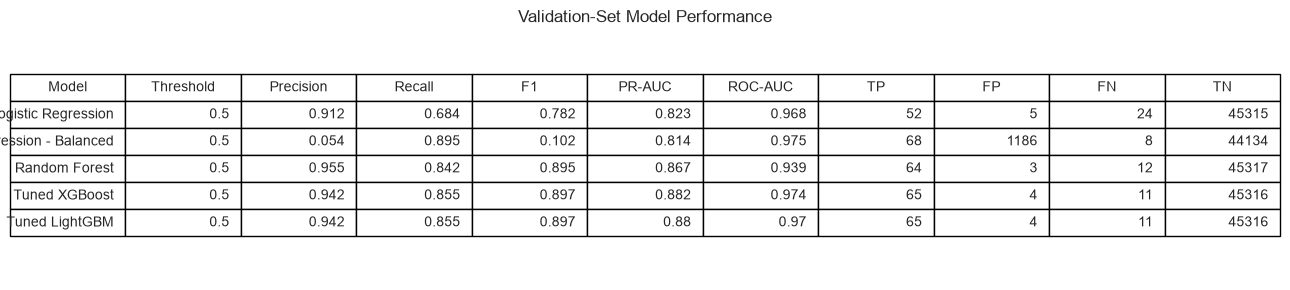

In [46]:
plot_table(
    validation_summary,
    title="Validation-Set Model Performance",
    figsize=(13, 3)
)

In [47]:
# Combine train + validation after all decisions are finalized
X_final_train = pd.concat([X_train, X_val])
y_final_train = pd.concat([y_train, y_val])

# Fresh model with selected hyperparameters
final_model = clone(best_xgb)

final_model.fit(
    X_final_train,
    y_final_train
)

# Final untouched test probabilities
y_test_prob = final_model.predict_proba(X_test)[:, 1]

# Use threshold chosen previously on VALIDATION data
final_threshold = best_threshold

y_test_pred = (
    y_test_prob >= final_threshold
).astype(int)

# Metrics
tn, fp, fn, tp = confusion_matrix(
    y_test,
    y_test_pred
).ravel()

final_test_results = pd.DataFrame({
    "Model": ["Tuned XGBoost"],
    "Threshold": [final_threshold],
    "Precision": [precision_score(y_test, y_test_pred)],
    "Recall": [recall_score(y_test, y_test_pred)],
    "F1": [f1_score(y_test, y_test_pred)],
    "ROC-AUC": [roc_auc_score(y_test, y_test_prob)],
    "PR-AUC": [average_precision_score(y_test, y_test_prob)],
    "TP": [tp],
    "FP": [fp],
    "FN": [fn],
    "TN": [tn]
}).round(3)

final_test_results

,Model,Threshold,Precision,Recall,F1,ROC-AUC,PR-AUC,TP,FP,FN,TN
0,Tuned XGBoost,0.69,0.959,0.747,0.84,0.975,0.826,71,3,24,56648


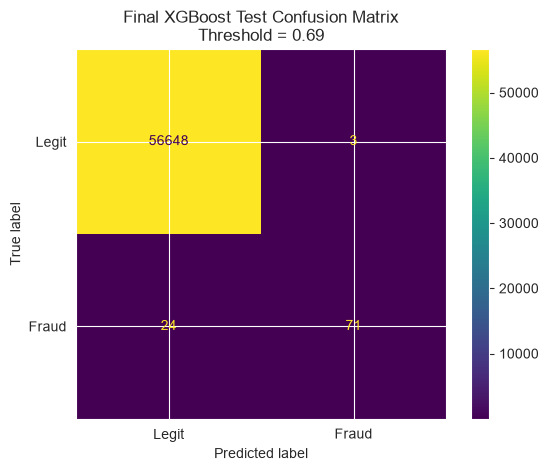

In [48]:
final_cm = confusion_matrix(
    y_test,
    y_test_pred
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=final_cm,
    display_labels=["Legit", "Fraud"]
)

disp.plot(values_format="d")

plt.title(
    f"Final XGBoost Test Confusion Matrix\n"
    f"Threshold = {final_threshold:.2f}"
)

plt.show()

# Final conclusions

This project evaluated several supervised classification approaches for detecting fraudulent credit-card transactions under severe class imbalance, with fraudulent transactions representing approximately 0.17% of the cleaned dataset.

## Data preparation and evaluation strategy

Exact duplicate copies were removed before data splitting to reduce the risk of identical observations appearing across training and evaluation subsets.

The cleaned data was divided using stratification into:

- 64% training data
- 16% validation data
- 20% final test data

The training set was used for model fitting, cross-validation, and hyperparameter optimization. The validation set was used for model comparison and classification-threshold selection. The final test set was kept separate until all modeling decisions had been completed.

Because fraud represents such a small minority of observations, accuracy was not considered an informative primary metric. Model selection focused primarily on PR-AUC, together with precision, recall, and F1-score. ROC-AUC was also reported for comparison.

## Model comparison

Logistic Regression provided a useful linear baseline. The unweighted model achieved strong precision but lower recall, indicating that it missed a substantial proportion of fraudulent transactions.

Applying balanced class weights substantially increased recall but caused precision and F1-score to collapse, demonstrating that aggressive imbalance correction can create an unacceptable number of false-positive fraud alerts.

The nonlinear tree-based models performed substantially better.

On the validation set:

- Random Forest achieved PR-AUC = 0.867 and F1 = 0.895.
- Tuned XGBoost achieved PR-AUC = 0.882 and F1 = 0.897.
- Tuned LightGBM achieved PR-AUC = 0.880 and F1 = 0.897.

Five-fold stratified cross-validation produced mean PR-AUC scores of approximately:

- Random Forest: 0.823 ± 0.040
- Tuned XGBoost: 0.846 ± 0.024
- Tuned LightGBM: 0.842 ± 0.030

XGBoost and LightGBM therefore performed very similarly. XGBoost was selected as the final candidate because it achieved the highest mean cross-validated PR-AUC, slightly higher validation PR-AUC, and relatively low fold-to-fold variability.

## Feature analysis

The exploratory analysis identified `V10`, `V12`, `V14`, `V16`, and `V17` as the PCA components with the strongest univariate separation between fraudulent and legitimate transactions.

All five appeared among the top 10 model features for both Random Forest and XGBoost, providing additional evidence that these components contain meaningful predictive signal. Feature rankings differed across model families, which is expected because different algorithms capture different types of relationships and interactions.

## Threshold optimization

The default classification threshold of 0.5 was not assumed to be optimal.

Threshold selection was performed exclusively on the validation set. In the absence of explicit business costs for false positives and false negatives, the threshold maximizing F1-score was selected.

The chosen threshold was:

**0.69**

At this threshold on the validation set, XGBoost achieved approximately:

- Precision: 0.985
- Recall: 0.842
- F1-score: 0.908

## Final held-out test performance

After all model and threshold decisions were finalized, the selected XGBoost model was retrained using the combined training and validation data and evaluated once on the previously untouched test set.

The final test performance was:

- Precision: **0.959**
- Recall: **0.747**
- F1-score: **0.840**
- PR-AUC: **0.826**
- ROC-AUC: **0.975**

At the selected threshold, the model:

- correctly detected 71 fraudulent transactions,
- produced only 3 false-positive fraud alerts,
- missed 24 fraudulent transactions,
- correctly classified 56,648 legitimate transactions.

Performance on the final test set was somewhat lower than on the validation set, particularly for recall and PR-AUC. Because the number of fraudulent observations is very small, these metrics are sensitive to a relatively small number of additional missed fraud cases.

The final model nevertheless retained very high precision and strong ranking performance.

## Practical interpretation

The selected threshold favors precision, producing very few false-positive fraud alerts. In a real fraud-detection system, however, the optimal threshold should be determined using the actual business costs of false positives and false negatives.

If missing a fraudulent transaction is substantially more costly than investigating a legitimate transaction, a lower threshold could be selected to prioritize recall instead.

Overall, tuned XGBoost provided the strongest combination of cross-validated performance, validation performance, and stability among the models evaluated.